## OOD_DATA EXPLORATION

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../data/raw/cifar-10-batches-py"

print("Existe a pasta?", os.path.exists(DATA_DIR))
print("Ficheiros encontrados:")
print(os.listdir(DATA_DIR))

Existe a pasta? True
Ficheiros encontrados:
['data_batch_3', 'data_batch_1', 'data_batch_5', 'data_batch_4', 'test_batch', 'readme.html', 'batches.meta', 'data_batch_2']


In [2]:
## Carregar os nomes das classes
def unpickle(file):
    with open(file, "rb") as fo:
        data = pickle.load(fo, encoding="bytes")
    return data

meta = unpickle(os.path.join(DATA_DIR, "batches.meta"))
class_names = [name.decode("utf-8") for name in meta[b"label_names"]]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
## Carregar um batch do CIFAR-10
batch_1 = unpickle(os.path.join(DATA_DIR, "data_batch_1"))

print(batch_1.keys())
print("Formato dos dados:", batch_1[b"data"].shape)
print("Número de labels:", len(batch_1[b"labels"]))

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
Formato dos dados: (10000, 3072)
Número de labels: 10000


In [4]:
images = batch_1[b"data"]
labels = batch_1[b"labels"]

images = images.reshape(-1, 3, 32, 32)
images = images.transpose(0, 2, 3, 1)

labels = np.array(labels)

print("Formato das imagens:", images.shape)
print("Formato das labels:", labels.shape)

Formato das imagens: (10000, 32, 32, 3)
Formato das labels: (10000,)


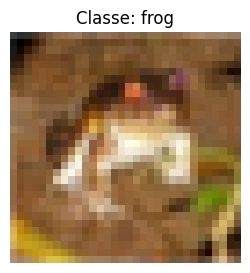

In [5]:
### Mostrar uma imagem individual
idx = 0
plt.figure(figsize=(3, 3))
plt.imshow(images[idx])
plt.title(f"Classe: {class_names[labels[idx]]}")
plt.axis("off")
plt.show()

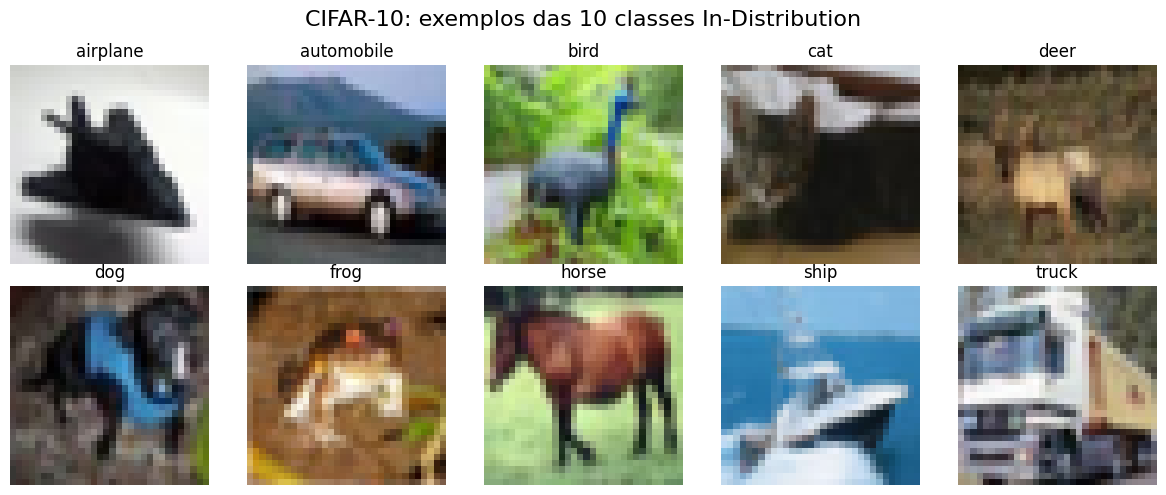

In [6]:
## Criar uma grelha com exemplos das 10 classes.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for class_id in range(10):
    idx = np.where(labels == class_id)[0][0]
    axes[class_id].imshow(images[idx])
    axes[class_id].set_title(class_names[class_id], fontsize=12)
    axes[class_id].axis("off")

plt.suptitle("CIFAR-10: exemplos das 10 classes In-Distribution", fontsize=16)
plt.tight_layout()
plt.show()

Figura guardada em: ../results/figures/cifar10_examples_grid.png


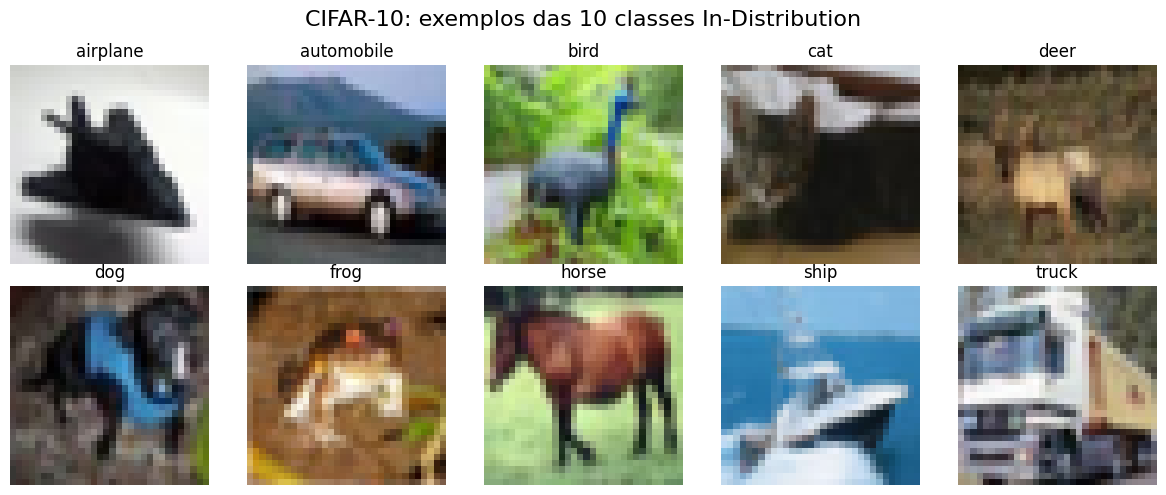

In [7]:
## GUARDAR NAS FIGURAS
os.makedirs("../results/figures", exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for class_id in range(10):
    idx = np.where(labels == class_id)[0][0]
    axes[class_id].imshow(images[idx])
    axes[class_id].set_title(class_names[class_id], fontsize=12)
    axes[class_id].axis("off")

plt.suptitle("CIFAR-10: exemplos das 10 classes In-Distribution", fontsize=16)
plt.tight_layout()

save_path = "../results/figures/cifar10_examples_grid.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
#plt.show()

print("Figura guardada em:", save_path)

In [ ]:
## Criar o carregador PyTorch do CIFAR-10 - via .py
